# ClarityNet: FullSubNet+ Training

This notebook:
1. Loads the train/val/test splits
2. Uses the FullSubNet+ model ([implementation](https://github.com/RookieJunChen/FullSubNet-plus/blob/master/speech_enhance/fullsubnet_plus/model/fullsubnet_plus.py)) with a wrapper.
3. Implements the training loop with validation on seen and unseen noise
4. Tracks the generalization gap during training
5. Saves checkpoints and training history

In [1]:
# Imports
import os
import sys
import json
import random
import numpy as np
# %matplotlib inline

from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# For module imports
PROJECT_ROOT = Path("../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.manifest import load_manifest

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("Imports successful!")

Imports successful!


In [2]:
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : NVIDIA GeForce RTX 2080 SUPER


## Configuration

In [3]:
# Training hyperparameters
BATCH_SIZE = 1         # Reduced from 8 for OOM fix
LEARNING_RATE = 1e-4   # Lower learning rate for stable training
NUM_EPOCHS = 50
PATIENCE = 10          # Early stopping patience
SAVE_EVERY = 5         # Save checkpoint every N epochs

# Memory optimization options
USE_MIXED_PRECISION = False          # Disable by default (can cause NaN with complex STFT). Enable if memory is critical.
GRADIENT_ACCUMULATION_STEPS = 8      # Accumulate gradients over 4 steps

# Paths
PROJECT_ROOT = Path("..").resolve() 
MANIFEST_PATH = PROJECT_ROOT / "data" / "MANIFEST.json"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "fullsubnet_plus_si_snr_eval"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_ROOT / "results" / "fullsubnet_plus_si_snr_eval"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Device
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    # Clear GPU cache before training
    torch.cuda.empty_cache()
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f"Configuration:")
print(f"  Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"  Batch size (train): {BATCH_SIZE}")
print(f"  Batch size (val): 1 (reduced for memory efficiency)")
print(f"  Gradient accumulation: {GRADIENT_ACCUMULATION_STEPS}x")
print(f"  Mixed precision: {USE_MIXED_PRECISION}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Checkpoint dir: {CHECKPOINT_DIR}")
print(f"  Results dir: {RESULTS_DIR}")

# If you still get OOM, try in this order:
print("\n⚠️  If you get OOM errors, try these in order:")
print("  1. Set BATCH_SIZE = 1")
print("  2. Reduce augmentation_factor from 3 to 1 in dataset creation")
print("  3. Skip PESQ/STOI: set COMPUTE_METRICS_EVERY = NUM_EPOCHS")
print("  4. Reduce SEGMENT_DURATION in src/data/audio_utils.py from 4.0 to 2.0")

Configuration:
  Device: cuda
  GPU Memory: 8.2 GB
  Batch size (train): 1
  Batch size (val): 1 (reduced for memory efficiency)
  Gradient accumulation: 8x
  Mixed precision: False
  Learning rate: 0.0001
  Epochs: 50
  Checkpoint dir: /home/paul/Desktop/projects/clarity-net/checkpoints/fullsubnet_plus_si_snr_eval
  Results dir: /home/paul/Desktop/projects/clarity-net/results/fullsubnet_plus_si_snr_eval

⚠️  If you get OOM errors, try these in order:
  1. Set BATCH_SIZE = 1
  2. Reduce augmentation_factor from 3 to 1 in dataset creation
  3. Skip PESQ/STOI: set COMPUTE_METRICS_EVERY = NUM_EPOCHS
  4. Reduce SEGMENT_DURATION in src/data/audio_utils.py from 4.0 to 2.0


## Create Datasets

In [4]:
from src.data.dataset import FullSubNetPlusDataset


print("Creating datasets...\n")

splits = load_manifest(MANIFEST_PATH)

train_dataset = FullSubNetPlusDataset(
    clean_files=splits['train'], 
    noise_files=splits['noise_seen'], 
    mode='train',
    augmentation_factor=5,
    base_seed=42,
    epoch=0
)

val_seen_dataset = FullSubNetPlusDataset(
    clean_files=splits['val'],
    noise_files=splits['noise_seen'],
    mode='val',
    eval_pairs_per_clean=3,
    base_seed=42
)

val_unseen_dataset = FullSubNetPlusDataset(
    clean_files=splits['val'],
    noise_files=splits['noise_unseen'],
    mode='val',
    eval_pairs_per_clean=3,
    base_seed=43
)

test_seen_dataset = FullSubNetPlusDataset(
    clean_files=splits['test'],
    noise_files=splits['noise_seen'],
    mode='test',
    eval_pairs_per_clean=3,
    base_seed=44
)

test_unseen_dataset = FullSubNetPlusDataset(
    clean_files=splits['test'],
    noise_files=splits['noise_unseen'],
    mode='test',
    eval_pairs_per_clean=3,
    base_seed=45
)

print("\n" + "="*60)
print(f"Training:          {len(train_dataset)} pairs")
print(f"Validation (seen): {len(val_seen_dataset)} pairs")
print(f"Validation (uns.): {len(val_unseen_dataset)} pairs")
print(f"Test (seen):       {len(test_seen_dataset)} pairs")
print(f"Test (uns.):       {len(test_unseen_dataset)} pairs")
print("="*60)

✓ Dataset classes defined
Creating datasets...

[FullSubNetPlus-TRAIN] Loading 160 clean files...
[FullSubNetPlus-TRAIN] Loading 38 noise files...
[FullSubNetPlus-TRAIN] 285 clean segments, 76 noise segments
[FullSubNetPlus-VAL] Loading 20 clean files...
[FullSubNetPlus-VAL] Loading 38 noise files...
[FullSubNetPlus-VAL] 36 clean segments, 76 noise segments
[FullSubNetPlus-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=3)...
[FullSubNetPlus-VAL] Total fixed pairs: 108
[FullSubNetPlus-VAL] Loading 20 clean files...
[FullSubNetPlus-VAL] Loading 22 noise files...
[FullSubNetPlus-VAL] 36 clean segments, 44 noise segments
[FullSubNetPlus-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=3)...
[FullSubNetPlus-VAL] Total fixed pairs: 108
[FullSubNetPlus-TEST] Loading 20 clean files...
[FullSubNetPlus-TEST] Loading 38 noise files...
[FullSubNetPlus-TEST] 33 clean segments, 76 noise segments
[FullSubNetPlus-TEST] Generating deterministic fixed pairs (eval_pairs_pe

## Create DataLoaders

In [5]:
# Ensure shuffling is deterministic for reproducibility
train_gen = torch.Generator().manual_seed(42)

# Use smaller batch size for validation to save memory
VAL_BATCH_SIZE = 1  # Validation can use batch_size=1 even if training uses batch_size=2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=train_gen)
val_seen_loader = DataLoader(val_seen_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=0)
val_unseen_loader = DataLoader(val_unseen_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=0)
test_seen_loader = DataLoader(test_seen_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=0)
test_unseen_loader = DataLoader(test_unseen_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoaders created:")
print(f"  Train batches: {len(train_loader)} (batch_size={BATCH_SIZE})")
print(f"  Val (seen) batches: {len(val_seen_loader)} (batch_size={VAL_BATCH_SIZE})")
print(f"  Val (unseen) batches: {len(val_unseen_loader)} (batch_size={VAL_BATCH_SIZE})")
print(f"  Test (seen) batches: {len(test_seen_loader)} (batch_size={VAL_BATCH_SIZE})")
print(f"  Test (unseen) batches: {len(test_unseen_loader)} (batch_size={VAL_BATCH_SIZE})")

DataLoaders created:
  Train batches: 1425 (batch_size=1)
  Val (seen) batches: 108 (batch_size=1)
  Val (unseen) batches: 108 (batch_size=1)
  Test (seen) batches: 99 (batch_size=1)
  Test (unseen) batches: 99 (batch_size=1)


## Define FullSubNet model

In [6]:
from pathlib import Path

root = Path("../src/external/fullsubnet_plus")
print("repo root exists:", root.exists())
print("audio_zen exists:", (root / "audio_zen").exists())
print("speech_enhance exists:", (root / "speech_enhance").exists())
print("model file exists:", (root / "speech_enhance/fullsubnet_plus/model/fullsubnet_plus.py").exists())

repo root exists: True
audio_zen exists: False
speech_enhance exists: True
model file exists: True


In [7]:
from src.models.fullsubnet_plus import FullSubNetPlusWrapper, count_parameters

# Create model
model = FullSubNetPlusWrapper(num_freqs=257).to(DEVICE)

print(f"Model created with {count_parameters(model):,} parameters")
print("✓ Model ready")

Model created with 8,658,899 parameters
✓ Model ready


## Training Setup

In [8]:
from src.training.losses import fullsubnet_plus_l1_loss
criterion = fullsubnet_plus_l1_loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (optional)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f"Loss function: Complex L1Loss")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Scheduler: ReduceLROnPlateau")

Loss function: Complex L1Loss
Optimizer: Adam (lr=0.0001)
Scheduler: ReduceLROnPlateau


Val seen SNR:
  count: 108
  mean:  10.21 dB
  std:   5.81 dB
  min:   0.14 dB
  q25:   4.58 dB
  q50:   10.75 dB
  q75:   15.21 dB
  max:   19.95 dB

Val unseen SNR:
  count: 108
  mean:  10.22 dB
  std:   5.55 dB
  min:   0.20 dB
  q25:   5.15 dB
  q50:   10.40 dB
  q75:   14.47 dB
  max:   19.78 dB



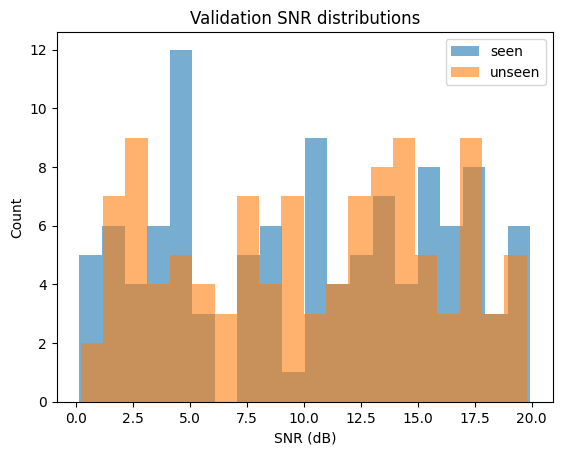

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def collect_snrs(loader):
    snrs = []
    for batch in loader:
        batch_snrs = batch["snr"]

        # handle tensor or plain list
        if hasattr(batch_snrs, "cpu"):
            snrs.extend(batch_snrs.cpu().numpy().tolist())
        else:
            snrs.extend(list(batch_snrs))

    return np.array(snrs, dtype=float)

def summarize_snrs(name, snrs):
    print(f"{name}:")
    print(f"  count: {len(snrs)}")
    print(f"  mean:  {snrs.mean():.2f} dB")
    print(f"  std:   {snrs.std():.2f} dB")
    print(f"  min:   {snrs.min():.2f} dB")
    print(f"  q25:   {np.percentile(snrs, 25):.2f} dB")
    print(f"  q50:   {np.percentile(snrs, 50):.2f} dB")
    print(f"  q75:   {np.percentile(snrs, 75):.2f} dB")
    print(f"  max:   {snrs.max():.2f} dB")
    print()

seen_snrs = collect_snrs(val_seen_loader)
unseen_snrs = collect_snrs(val_unseen_loader)

summarize_snrs("Val seen SNR", seen_snrs)
summarize_snrs("Val unseen SNR", unseen_snrs)

plt.hist(seen_snrs, bins=20, alpha=0.6, label="seen")
plt.hist(unseen_snrs, bins=20, alpha=0.6, label="unseen")
plt.xlabel("SNR (dB)")
plt.ylabel("Count")
plt.title("Validation SNR distributions")
plt.legend()
plt.show()

## Run Training

In [10]:
## Diagnostic: Test First Batch

# Test loss on first batch to catch NaN issues before training
print("Testing loss on first batch...")

model.eval()
with torch.no_grad():
    batch = next(iter(train_loader))
    
    noisy_mag = batch["noisy_mag"].to(DEVICE)
    noisy_real = batch["noisy_real"].to(DEVICE)
    noisy_imag = batch["noisy_imag"].to(DEVICE)
    clean_mag = batch["clean_mag"].to(DEVICE)
    clean_real = batch["clean_real"].to(DEVICE)
    clean_imag = batch["clean_imag"].to(DEVICE)
    
    print(f"  noisy_mag:  shape={noisy_mag.shape}, min={noisy_mag.min():.6f}, max={noisy_mag.max():.6f}, has_nan={torch.isnan(noisy_mag).any()}")
    print(f"  noisy_real: shape={noisy_real.shape}, min={noisy_real.min():.6f}, max={noisy_real.max():.6f}, has_nan={torch.isnan(noisy_real).any()}")
    print(f"  noisy_imag: shape={noisy_imag.shape}, min={noisy_imag.min():.6f}, max={noisy_imag.max():.6f}, has_nan={torch.isnan(noisy_imag).any()}")
    print(f"  clean_mag:  shape={clean_mag.shape}, min={clean_mag.min():.6f}, max={clean_mag.max():.6f}, has_nan={torch.isnan(clean_mag).any()}")
    print(f"  clean_real: shape={clean_real.shape}, min={clean_real.min():.6f}, max={clean_real.max():.6f}, has_nan={torch.isnan(clean_real).any()}")
    print(f"  clean_imag: shape={clean_imag.shape}, min={clean_imag.min():.6f}, max={clean_imag.max():.6f}, has_nan={torch.isnan(clean_imag).any()}")
    
    # Forward pass
    pred_mask = model(noisy_mag, noisy_real, noisy_imag)
    print(f"\n  pred_mask: shape={pred_mask.shape}, min={pred_mask.min():.6f}, max={pred_mask.max():.6f}, has_nan={torch.isnan(pred_mask).any()}")
    
    # Apply mask
    enh_real, enh_imag = model.apply_mask(pred_mask, noisy_real, noisy_imag)
    enh_mag = torch.sqrt(enh_real.pow(2) + enh_imag.pow(2) + 1e-8)
    
    print(f"  enh_real: shape={enh_real.shape}, min={enh_real.min():.6f}, max={enh_real.max():.6f}, has_nan={torch.isnan(enh_real).any()}")
    print(f"  enh_imag: shape={enh_imag.shape}, min={enh_imag.min():.6f}, max={enh_imag.max():.6f}, has_nan={torch.isnan(enh_imag).any()}")
    print(f"  enh_mag:  shape={enh_mag.shape}, min={enh_mag.min():.6f}, max={enh_mag.max():.6f}, has_nan={torch.isnan(enh_mag).any()}")
    
    # Compute loss
    loss = criterion(
        enh_real, enh_imag, clean_real, clean_imag,
        enhanced_mag=enh_mag, clean_mag=clean_mag, pred_mask=pred_mask
    )
    print(f"\n  loss: {loss:.6f}, is_nan={torch.isnan(loss).item()}")
    
    if torch.isnan(loss):
        print("\n⚠️  NaN DETECTED IN LOSS!")
        # Check each component
        l1_real = torch.nn.functional.l1_loss(enh_real, clean_real)
        l1_imag = torch.nn.functional.l1_loss(enh_imag, clean_imag)
        l1_mag = torch.nn.functional.l1_loss(enh_mag, clean_mag)
        print(f"    L1(real): {l1_real:.6f}, is_nan={torch.isnan(l1_real).item()}")
        print(f"    L1(imag): {l1_imag:.6f}, is_nan={torch.isnan(l1_imag).item()}")
        print(f"    L1(mag):  {l1_mag:.6f}, is_nan={torch.isnan(l1_mag).item()}")
    else:
        print("✓ Loss is valid (no NaN)")

model.train()

# Clean up GPU memory
del batch, noisy_mag, noisy_real, noisy_imag, clean_mag, clean_real, clean_imag
del pred_mask, enh_real, enh_imag, enh_mag, loss
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\n✓ GPU memory cleaned up before training")

Testing loss on first batch...
  noisy_mag:  shape=torch.Size([1, 257, 501]), min=0.000000, max=5.759744, has_nan=False
  noisy_real: shape=torch.Size([1, 257, 501]), min=-4.727651, max=5.547868, has_nan=False
  noisy_imag: shape=torch.Size([1, 257, 501]), min=-5.664855, max=5.039123, has_nan=False
  clean_mag:  shape=torch.Size([1, 257, 501]), min=0.000000, max=5.759744, has_nan=False
  clean_real: shape=torch.Size([1, 257, 501]), min=-4.727651, max=5.547868, has_nan=False
  clean_imag: shape=torch.Size([1, 257, 501]), min=-5.664855, max=5.039123, has_nan=False

  pred_mask: shape=torch.Size([1, 2, 257, 501]), min=-1.110324, max=0.192695, has_nan=False
  enh_real: shape=torch.Size([1, 257, 501]), min=-4.348099, max=3.855961, has_nan=False
  enh_imag: shape=torch.Size([1, 257, 501]), min=-4.065672, max=4.031159, has_nan=False
  enh_mag:  shape=torch.Size([1, 257, 501]), min=0.000100, max=4.349286, has_nan=False

  loss: 0.119496, is_nan=False
✓ Loss is valid (no NaN)

✓ GPU memory clea

In [11]:
%%time

"""
Updated training loop with PESQ/STOI metrics and memory optimizations.
"""

from src.models.model_utils import save_checkpoint, train_epoch
from src.evaluation.metrics import validate_with_metrics

# Training history - EXPANDED to include PESQ/STOI/SI-SNR and generalization gaps
history = {
    'train_loss': [],
    'val_seen_loss': [],
    'val_seen_pesq': [],
    'val_seen_stoi': [],
    'val_seen_si_snr': [],
    'val_unseen_loss': [],
    'val_unseen_pesq': [],
    'val_unseen_stoi': [],
    'val_unseen_si_snr': [],
    'generalization_gap_loss': [],
    'generalization_gap_pesq': [],
    'generalization_gap_stoi': [],
    'generalization_gap_si_snr': [],
    'learning_rate': []
}

best_val_loss = float('inf')
epochs_without_improvement = 0

# Memory-efficient validation: only compute PESQ/STOI every N epochs
COMPUTE_METRICS_EVERY = 1  # Only compute expensive metrics every 5 epochs

print("="*70)
print("Starting Training with PESQ/STOI/SI-SNR Tracking + Memory Optimizations")
print("="*70)
print(f"Note: Computing PESQ/STOI/SI-SNR every {COMPUTE_METRICS_EVERY} epochs to save memory\n")

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print("-" * 70)
    
    # Update dataset epoch for deterministic augmentation
    train_dataset.set_epoch(epoch)
    
    # Train with memory optimizations
    train_loss = train_epoch(
        model, 
        train_loader, 
        criterion, 
        optimizer, 
        device=DEVICE,
        use_mixed_precision=USE_MIXED_PRECISION,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS
    )
    
    # Only compute expensive metrics every N epochs
    compute_metrics_this_epoch = (epoch % COMPUTE_METRICS_EVERY == 0) or (epoch == 1)
    
    if compute_metrics_this_epoch:
        # Validate with metrics (PESQ/STOI computed on small subset)
        val_seen_metrics = validate_with_metrics(
            model=model, 
            loader=val_seen_loader, 
            criterion=criterion, 
            device=DEVICE,
            max_pesq_samples=20  # Reduced from 100 to save memory
        )
        
        val_unseen_metrics = validate_with_metrics(
            model=model,
            loader=val_unseen_loader,
            criterion=criterion,
            device=DEVICE,
            max_pesq_samples=20
        )
        
        # Compute gaps
        gap_loss = val_unseen_metrics['loss'] - val_seen_metrics['loss']
        gap_pesq = val_seen_metrics['pesq'] - val_unseen_metrics['pesq']  # Note: Higher PESQ is better
        gap_stoi = val_seen_metrics['stoi'] - val_unseen_metrics['stoi']  # Note: Higher STOI is better
        gap_si_snr = val_seen_metrics['si_snr'] - val_unseen_metrics['si_snr']  # Note: Higher SI-SNR is better
    else:
        # On non-metric epochs, only compute loss (fast and memory-efficient)
        val_seen_metrics = validate_with_metrics(
            model=model, 
            loader=val_seen_loader, 
            criterion=criterion, 
            device=DEVICE,
            max_pesq_samples=0  # Skip PESQ/STOI computation
        )
        
        val_unseen_metrics = validate_with_metrics(
            model=model,
            loader=val_unseen_loader,
            criterion=criterion,
            device=DEVICE,
            max_pesq_samples=0
        )
        
        # Use previous metrics or zeros
        if history['val_seen_pesq']:
            val_seen_metrics['pesq'] = history['val_seen_pesq'][-1]
            val_seen_metrics['stoi'] = history['val_seen_stoi'][-1]
        else:
            val_seen_metrics['pesq'] = 0.0
            val_seen_metrics['stoi'] = 0.0
            
        if history['val_unseen_pesq']:
            val_unseen_metrics['pesq'] = history['val_unseen_pesq'][-1]
            val_unseen_metrics['stoi'] = history['val_unseen_stoi'][-1]
        else:
            val_unseen_metrics['pesq'] = 0.0
            val_unseen_metrics['stoi'] = 0.0
        
        gap_loss = val_unseen_metrics['loss'] - val_seen_metrics['loss']
        gap_pesq = val_seen_metrics['pesq'] - val_unseen_metrics['pesq']
        gap_stoi = val_seen_metrics['stoi'] - val_unseen_metrics['stoi']
    
    # Update scheduler
    scheduler.step(val_seen_metrics['loss'])
    current_lr = optimizer.param_groups[0]['lr']
    
    # Log everything
    history['train_loss'].append(train_loss)
    history['val_seen_loss'].append(val_seen_metrics['loss'])
    history['val_seen_pesq'].append(val_seen_metrics['pesq'])
    history['val_seen_stoi'].append(val_seen_metrics['stoi'])
    history['val_seen_si_snr'].append(val_seen_metrics['si_snr'])
    history['val_unseen_loss'].append(val_unseen_metrics['loss'])
    history['val_unseen_pesq'].append(val_unseen_metrics['pesq'])
    history['val_unseen_stoi'].append(val_unseen_metrics['stoi'])
    history['val_unseen_si_snr'].append(val_unseen_metrics['si_snr'])
    history['generalization_gap_loss'].append(gap_loss)
    history['generalization_gap_pesq'].append(gap_pesq)
    history['generalization_gap_stoi'].append(gap_stoi)
    history['generalization_gap_si_snr'].append(gap_si_snr)
    history['learning_rate'].append(current_lr)
    
    # Pretty print results
    print(f"\nResults:")
    print(f"  Train Loss:         {train_loss:.6f}")
    print(f"  Val (seen)   - Loss: {val_seen_metrics['loss']:.6f}  "
          f"PESQ: {val_seen_metrics['pesq']:.3f}  "
          f"STOI: {val_seen_metrics['stoi']:.3f}"
          f"SI-SNR: {val_seen_metrics['si_snr']:.3f}")
    print(f"  Val (unseen) - Loss: {val_unseen_metrics['loss']:.6f}  "
          f"PESQ: {val_unseen_metrics['pesq']:.3f}  "
          f"STOI: {val_unseen_metrics['stoi']:.3f}"
          f"SI-SNR: {val_unseen_metrics['si_snr']:.3f}")
    print(f"  Gen. Gap     - Loss: {gap_loss:+.6f}  "
          f"PESQ: {gap_pesq:+.3f}  "
          f"STOI: {gap_stoi:+.3f}"
          f"SI-SNR: {gap_si_snr:+.3f}")
    print(f"  Learning Rate:      {current_lr:.2e}")
    
    if not compute_metrics_this_epoch:
        print(f"  (Metrics skipped - computed every {COMPUTE_METRICS_EVERY} epochs)")
    
    # Checkpointing (based on loss)
    if val_seen_metrics['loss'] < best_val_loss:
        best_val_loss = val_seen_metrics['loss']
        epochs_without_improvement = 0
        save_checkpoint(model, history, epoch, optimizer, scheduler, best_val_loss, CHECKPOINT_DIR, is_best=True)
        print("  ✓ New best model!")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement for {epochs_without_improvement} epoch(s)")
    
    if epoch % SAVE_EVERY == 0:
        save_checkpoint(model, history, epoch, optimizer, scheduler, best_val_loss, CHECKPOINT_DIR, is_best=False)
    
    # Clear GPU cache after each epoch
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\n⚠️  Early stopping triggered after {epoch} epochs")
        break

print("\n" + "="*70)
print("Training Complete!")
print(f"Best validation loss: {best_val_loss:.6f}")
print("="*70)

# Save final history
with open(RESULTS_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f"Training history saved to {RESULTS_DIR / 'training_history.json'}")

# Print final summary
if history['val_seen_pesq']:
    print("\nFinal Metrics Summary:")
    print(f"  Seen   - PESQ: {history['val_seen_pesq'][-1]:.3f}, STOI: {history['val_seen_stoi'][-1]:.3f}, SI-SNR: {history['val_seen_si_snr'][-1]:.3f}")
    print(f"  Unseen - PESQ: {history['val_unseen_pesq'][-1]:.3f}, STOI: {history['val_unseen_stoi'][-1]:.3f}, SI-SNR: {history['val_unseen_si_snr'][-1]:.3f}")
    if history['generalization_gap_pesq'][-1] != 0:
        print(f"  Gap    - PESQ: {history['generalization_gap_pesq'][-1]:+.3f}, STOI: {history['generalization_gap_stoi'][-1]:+.3f}, SI-SNR: {history['generalization_gap_si_snr'][-1]:+.3f}")

Starting Training with PESQ/STOI/SI-SNR Tracking + Memory Optimizations
Note: Computing PESQ/STOI/SI-SNR every 1 epochs to save memory


Epoch 1/50
----------------------------------------------------------------------


Training: 100%|██████████| 1425/1425 [08:54<00:00,  2.66it/s, loss=0.072446]



Results:
  Train Loss:         0.064496
  Val (seen)   - Loss: 0.083018  PESQ: 2.241  STOI: 0.896SI-SNR: 9.147
  Val (unseen) - Loss: 0.070887  PESQ: 2.307  STOI: 0.914SI-SNR: 10.689
  Gen. Gap     - Loss: -0.012131  PESQ: -0.066  STOI: -0.019SI-SNR: -1.543
  Learning Rate:      1.00e-04
  ✓ Saved best model to /home/paul/Desktop/projects/clarity-net/checkpoints/fullsubnet_plus_si_snr_eval/best_model.pth
  ✓ New best model!

Epoch 2/50
----------------------------------------------------------------------


Training: 100%|██████████| 1425/1425 [08:02<00:00,  2.95it/s, loss=0.029735]



Results:
  Train Loss:         0.058122
  Val (seen)   - Loss: 0.079671  PESQ: 2.270  STOI: 0.896SI-SNR: 9.248
  Val (unseen) - Loss: 0.069495  PESQ: 2.354  STOI: 0.914SI-SNR: 11.024
  Gen. Gap     - Loss: -0.010176  PESQ: -0.084  STOI: -0.018SI-SNR: -1.776
  Learning Rate:      1.00e-04
  ✓ Saved best model to /home/paul/Desktop/projects/clarity-net/checkpoints/fullsubnet_plus_si_snr_eval/best_model.pth
  ✓ New best model!

Epoch 3/50
----------------------------------------------------------------------


...


Results:
  Train Loss:         0.022983
  Val (seen)   - Loss: 0.031625  PESQ: 2.602  STOI: 0.906SI-SNR: 17.497
  Val (unseen) - Loss: 0.039624  PESQ: 2.586  STOI: 0.924SI-SNR: 14.397
  Gen. Gap     - Loss: +0.008000  PESQ: +0.017  STOI: -0.018SI-SNR: +3.100
  Learning Rate:      5.00e-05
  ✓ Saved best model to /home/paul/Desktop/projects/clarity-net/checkpoints/fullsubnet_plus_si_snr_eval/best_model.pth
  ✓ New best model!

Epoch 49/50
----------------------------------------------------------------------


Training: 100%|██████████| 1425/1425 [07:58<00:00,  2.98it/s, loss=0.006974]



Results:
  Train Loss:         0.024300
  Val (seen)   - Loss: 0.031844  PESQ: 2.608  STOI: 0.902SI-SNR: 17.075
  Val (unseen) - Loss: 0.037916  PESQ: 2.600  STOI: 0.925SI-SNR: 14.840
  Gen. Gap     - Loss: +0.006072  PESQ: +0.008  STOI: -0.023SI-SNR: +2.234
  Learning Rate:      5.00e-05
  No improvement for 1 epoch(s)

Epoch 50/50
----------------------------------------------------------------------


Training: 100%|██████████| 1425/1425 [07:56<00:00,  2.99it/s, loss=0.076247]



Results:
  Train Loss:         0.023974
  Val (seen)   - Loss: 0.031426  PESQ: 2.605  STOI: 0.902SI-SNR: 17.259
  Val (unseen) - Loss: 0.038188  PESQ: 2.596  STOI: 0.925SI-SNR: 14.847
  Gen. Gap     - Loss: +0.006762  PESQ: +0.009  STOI: -0.023SI-SNR: +2.412
  Learning Rate:      5.00e-05
  ✓ Saved best model to /home/paul/Desktop/projects/clarity-net/checkpoints/fullsubnet_plus_si_snr_eval/best_model.pth
  ✓ New best model!
  ✓ Saved checkpoint to /home/paul/Desktop/projects/clarity-net/checkpoints/fullsubnet_plus_si_snr_eval/checkpoint_epoch_50.pth

Training Complete!
Best validation loss: 0.031426
Training history saved to /home/paul/Desktop/projects/clarity-net/results/fullsubnet_plus_si_snr_eval/training_history.json

Final Metrics Summary:
  Seen   - PESQ: 2.605, STOI: 0.902, SI-SNR: 17.259
  Unseen - PESQ: 2.596, STOI: 0.925, SI-SNR: 14.847
  Gap    - PESQ: +0.009, STOI: -0.023, SI-SNR: +2.412
CPU times: user 4h 20min 1s, sys: 4h 20min 3s, total: 8h 40min 4s
Wall time: 6h 59min

In [12]:
print(f"Model trained with {count_parameters(model):,} parameters")

Model trained with 8,658,899 parameters


## Visualize Training

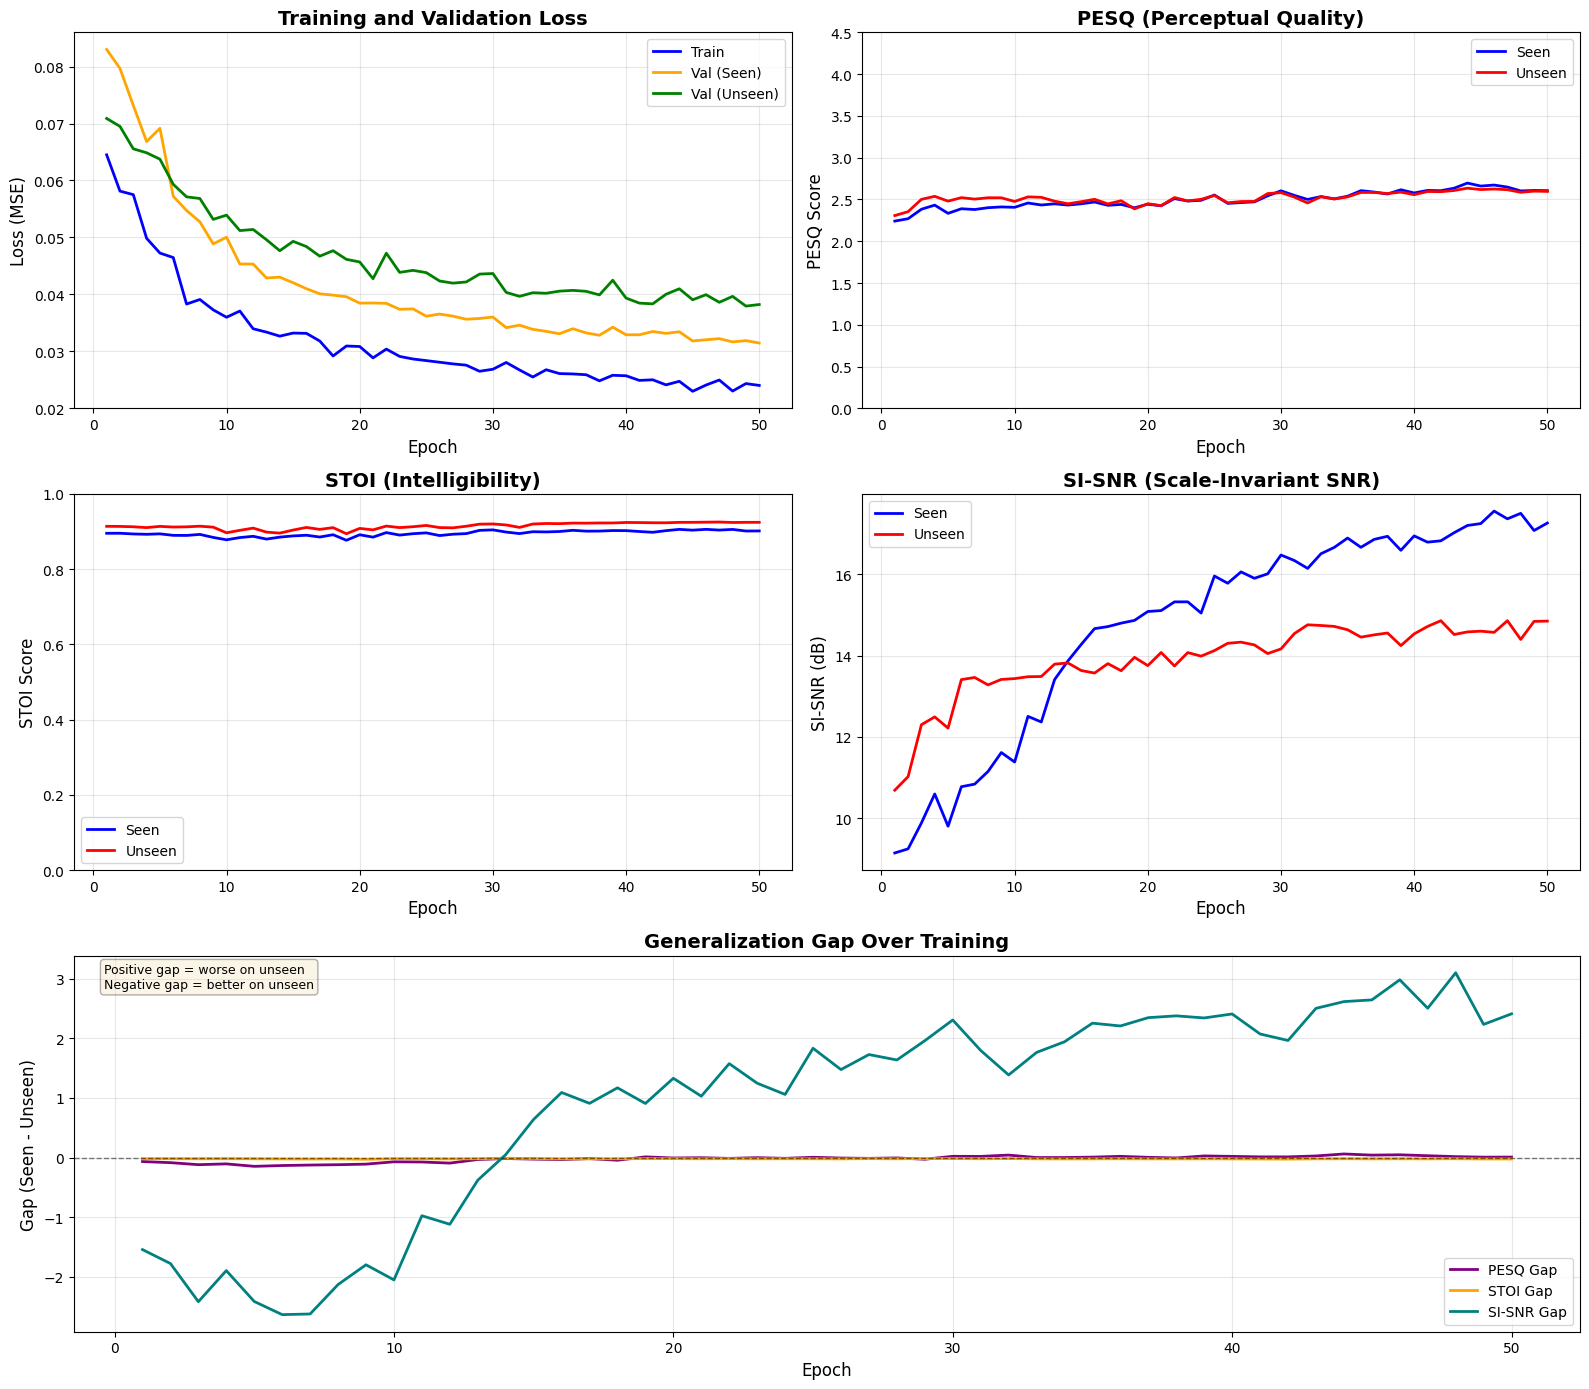

✓ Saved training curves to /home/paul/Desktop/projects/clarity-net/results/fullsubnet_plus_si_snr_eval/training_curves_with_metrics.png

Training Summary

Best epoch: 50
  Loss (seen):   0.031426
  Loss (unseen): 0.038188
  PESQ (seen):   2.605
  PESQ (unseen): 2.596
  STOI (seen):   0.902
  STOI (unseen): 0.925
  SI-SNR (seen): 17.259 dB
  SI-SNR (unseen): 14.847 dB

Final epoch: 50
  Loss (seen):   0.031426
  Loss (unseen): 0.038188
  PESQ (seen):   2.605
  PESQ (unseen): 2.596
  STOI (seen):   0.902
  STOI (unseen): 0.925
  SI-SNR (seen): 17.259 dB
  SI-SNR (unseen): 14.847 dB

Generalization Gaps (at best epoch):
  PESQ: +0.009
  STOI: -0.023
  SI-SNR: +2.412 dB

Generalization Gaps (at final epoch):
  PESQ: +0.009
  STOI: -0.023
  SI-SNR: +2.412 dB


In [13]:
from src.evaluation.visualize import plot_loss_curves

plot_loss_curves(history, RESULTS_DIR)

## Run Evaluation

In [14]:
from src.evaluation.evaluate import evaluate_model

checkpoint = torch.load(CHECKPOINT_DIR / "best_model.pth", map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

results_seen, results_unseen = evaluate_model(model, test_seen_loader, test_unseen_loader, RESULTS_DIR, device=DEVICE)

Evaluating Model

Evaluating on SEEN noise types...


Test (Seen): 100%|██████████| 99/99 [00:14<00:00,  6.67it/s]



Evaluating on UNSEEN noise types...


Test (Unseen): 100%|██████████| 99/99 [00:14<00:00,  6.70it/s]


Results Summary

SEEN Noise Types:
  MSE:  0.004513
  PESQ: 2.640 ± 0.945
  STOI: 0.920 ± 0.090
  SI-SNR: 18.236 ± 8.562

UNSEEN Noise Types:
  MSE:  0.011047
  PESQ: 2.276 ± 0.759
  STOI: 0.899 ± 0.097
  SI-SNR: 13.588 ± 6.172

Generalization Gap:
  PESQ: 0.364
  STOI: 0.020
  SI-SNR: 4.648

✓ Results saved to /home/paul/Desktop/projects/clarity-net/results/fullsubnet_plus_si_snr_eval/evaluation_results.json


## Visualize Audio Samples

Sample 1 - SNR: 10.4 dB
  PESQ: 1.545
  STOI: 0.910



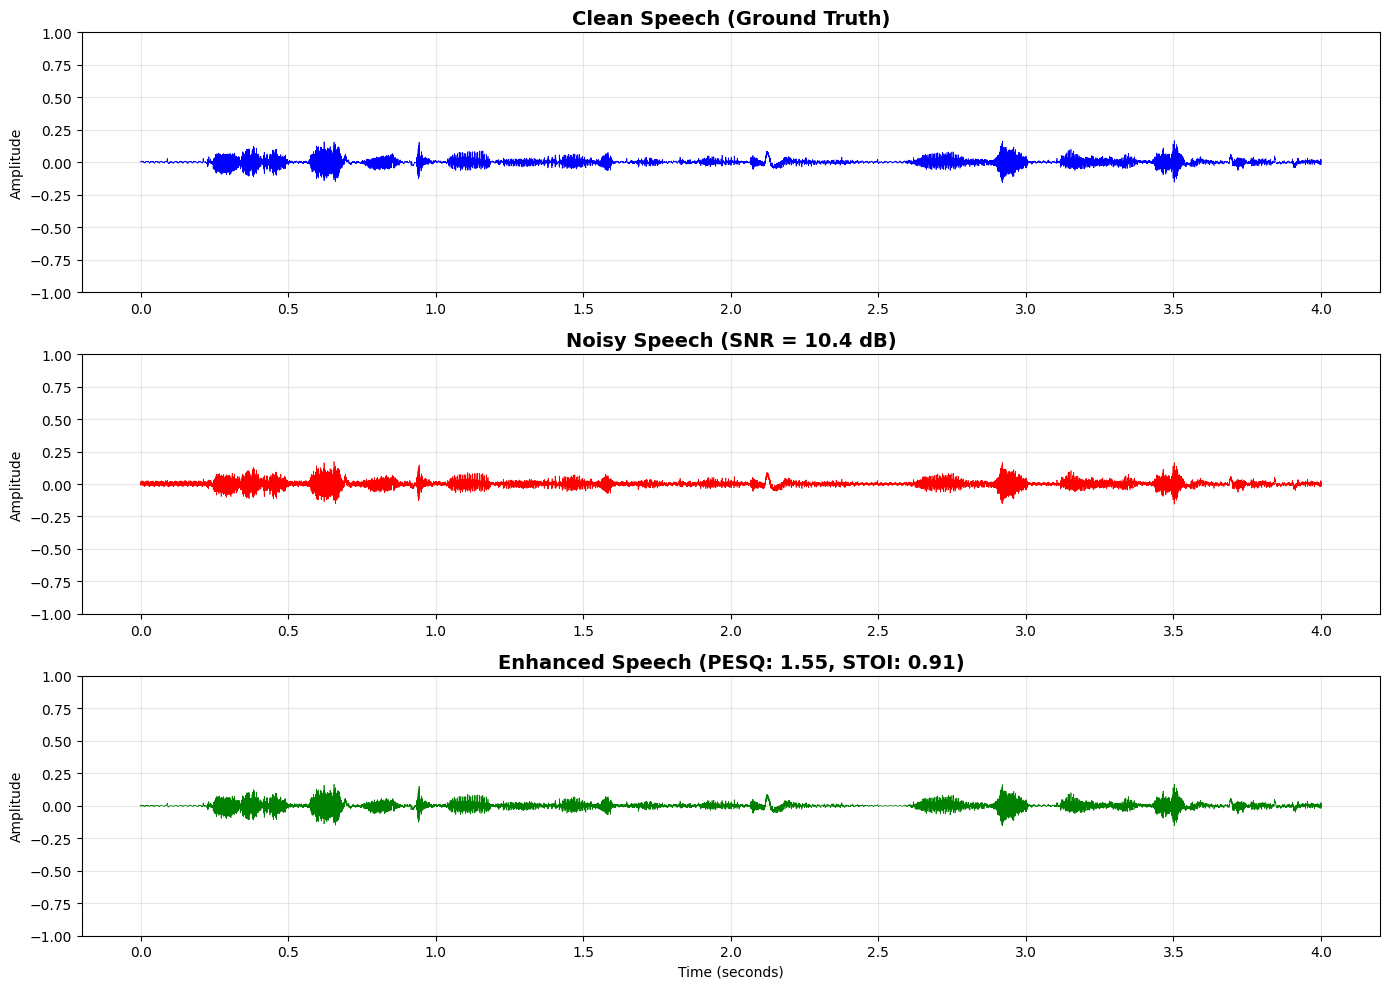

Waveform saved to /home/paul/Desktop/projects/clarity-net/results/fullsubnet_plus_si_snr_eval/waveform_comparison_sample_0.png


In [15]:
from src.evaluation.visualize import visualize_audio_samples

visualize_audio_samples(results_seen, RESULTS_DIR)

## Overlay Plots

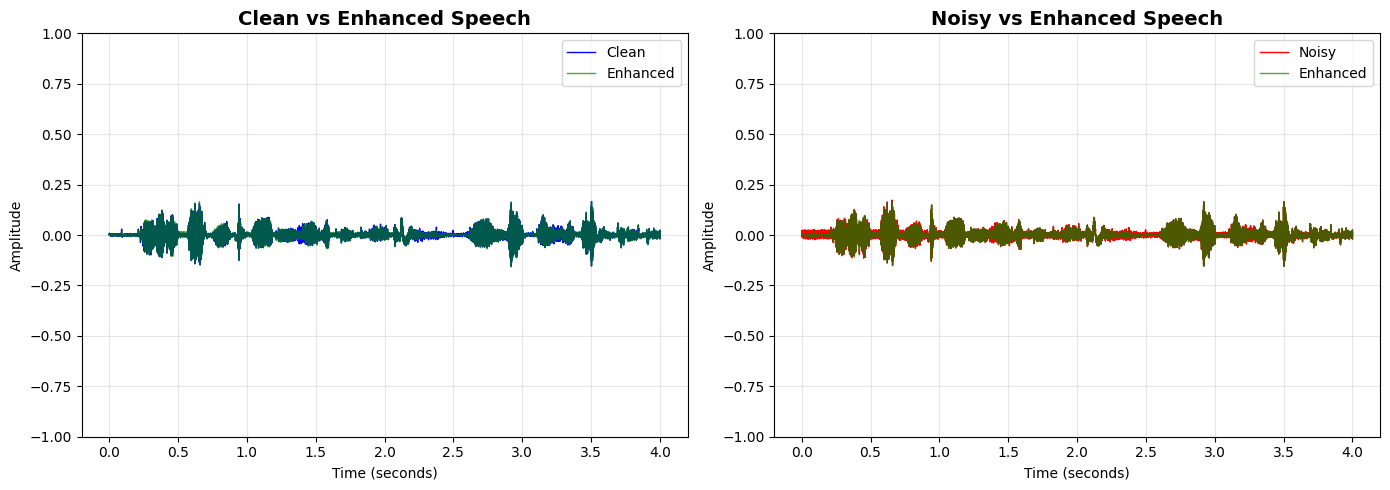

Overlay plots saved to /home/paul/Desktop/projects/clarity-net/results/fullsubnet_plus_si_snr_eval/overlay_comparison.png


In [16]:
from src.evaluation.visualize import visualize_audio_overlay

visualize_audio_overlay(results_seen, RESULTS_DIR)

## Audio Playback

In [17]:
from src.evaluation.visualize import playback_audio

playback_audio(results_seen)

Audio Data Inspection:
Sample rate: 16000 Hz
Clean audio shape: (64000,)
Clean audio dtype: float32
Clean audio range: [-0.156769, 0.166138]
Clean audio RMS: 0.019491
Clean audio duration: 4.00 seconds

Noisy audio shape: (64000,)
Noisy audio range: [-0.155119, 0.172804]
Noisy audio RMS: 0.020349

Enhanced audio shape: (64000,)
Enhanced audio range: [-0.155407, 0.165878]
Enhanced audio RMS: 0.019355

Clean Speech:



Noisy Speech (SNR = 10.4 dB):



Enhanced Speech (PESQ = 1.55, STOI = 0.91):


## Plot Metric Distributions

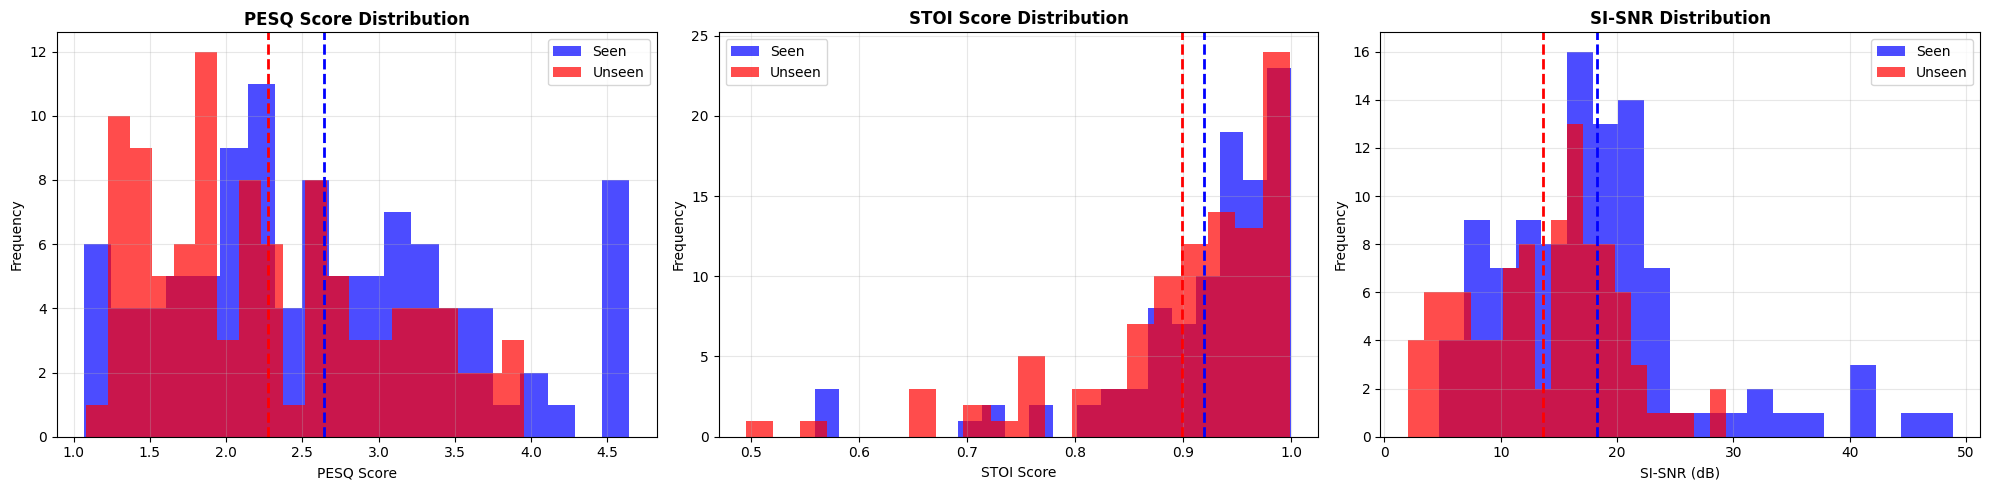

Metric distributions saved to /home/paul/Desktop/projects/clarity-net/results/fullsubnet_plus_si_snr_eval/metric_distributions.png


In [18]:
from src.evaluation.visualize import plot_metric_distributions

plot_metric_distributions(results_seen, results_unseen, RESULTS_DIR)